# 1. Préliminaires

## 1.1. Contexte 

Student Exam Performance Dataset Analysis : [Dataset](https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis/data)
Ce dataset utilisé dans ce repository pour pratiquer l'analyse de donnée.

## 1.2 Importations des librairies

In [59]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

## 1.3 Chargement des données

In [60]:
# chargement des données
data = pd.read_csv('./data/StudentPerformanceFactors.csv')

# Affichage d'un extrait
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 1.4 Structure et typologie des données
Affichage des dimensions et types des colonnes.

In [61]:
# Affichage des dimensions du dataframe
data.shape

(6607, 20)

In [62]:
# Affichage des informations sur les colonnes
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

# 2. Analyse Exploratoire des données
Nous allons réaliser une analyse exploratoire des données.

## 2.1 Changement du type de certaines colonnes

In [63]:
categorical_cols = [
    "Distance_from_Home",
    "Gender",
    "Parental_Education_Level",
    "Teacher_Quality",
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Internet_Access",
    "School_Type",
    "Peer_Influence",
    "Learning_Disabilities",
    "Family_Income"
]
data[categorical_cols] = data[categorical_cols].astype("category")

data[categorical_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Distance_from_Home        6540 non-null   category
 1   Gender                    6607 non-null   category
 2   Parental_Education_Level  6517 non-null   category
 3   Teacher_Quality           6529 non-null   category
 4   Parental_Involvement      6607 non-null   category
 5   Access_to_Resources       6607 non-null   category
 6   Motivation_Level          6607 non-null   category
 7   Internet_Access           6607 non-null   category
 8   School_Type               6607 non-null   category
 9   Peer_Influence            6607 non-null   category
 10  Learning_Disabilities     6607 non-null   category
 11  Family_Income             6607 non-null   category
dtypes: category(12)
memory usage: 78.1 KB


## 2.2 Exploration et Nettoyage
Ici nous allons explorer les données et faire du nettoyage.

In [64]:
# Affichage des statistiques de la méthode .describe()
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [65]:
# verification des valeurs nan
data.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [66]:
# Suppresion des valeurs manquantes
data.dropna(subset=['Teacher_Quality','Distance_from_Home','Parental_Education_Level'],inplace=True)

In [67]:
data.isna().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [68]:
# verification de la suppression des valeurs nulles
display("Somme des valeurs manquantes",data.isnull().sum())
display("Nouvelles dimensions ",data.shape)

'Somme des valeurs manquantes'

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

'Nouvelles dimensions '

(6378, 20)

In [69]:
# verifications des valeurs dupliquées
data.duplicated().sum()

np.int64(0)

In [70]:
# verification du nombre des valeurs uniques
data.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

In [71]:
# Verification du nombre des valeurs de Tutoring_Sessions vu que le maximum est très éloigné du troisième quartile
data.loc[data["Tutoring_Sessions"]>2,"Tutoring_Sessions"].value_counts()

Tutoring_Sessions
3    800
4    296
5    101
6     18
7      7
8      1
Name: count, dtype: int64

 ## 2.3 Analyse Univariée

Nous allons étudier certaines variables individuellement.

Nous allons d'abord créer des fonctions qui nous aideront pour les graphiques.

In [72]:
# Cette fonction retourne un diagramme circulaire

def get_pie_repartition_chart(series:pd.Series,title:str,palette:str):
    """_summary_

    Args:
        series (pd.Series): la series à utiliser.
        title (str): le titre du graphique
        palette (str): le nom de la palette de couleur
    """

    # On récupère les comptes
    count = series.value_counts()

    # Récupération des labels
    labels = count.index.to_list()

    # Choix de la palette de couleur
    colors = sns.color_palette(palette,n_colors=len(labels))

    # Initialisation de la figure
    plt.figure(figsize=(9,6))

    # Pie chart avec un pourcentage 2 chiffres après la virgule et un angle qui commence à 90
    plt.pie(count,autopct='%1.2f%%',startangle=90,labels=labels,colors=colors)

    # Titre du graphique
    plt.title(title)

    # Affichage du graphique
    plt.show()

In [73]:
# Cette fonction retourne un histogramme

def get_histogram(series:pd.Series,title:str):
    """_summary_

    Args:
        series (pd.Series): Series à utiliser
        title (str): titre du graphique
    """
    # Initialisation de la figure
    plt.figure(figsize=(9, 6))

    # histogramme
    sns.histplot(x=series)

    # Graduation de l'axe x
    plt.xticks(ticks=[i * 5 for i in range(21)])

    # Titre du graphique
    plt.title(title)

    # Affichage du graphique
    plt.show()

### 2.3.1 Repartition par genre

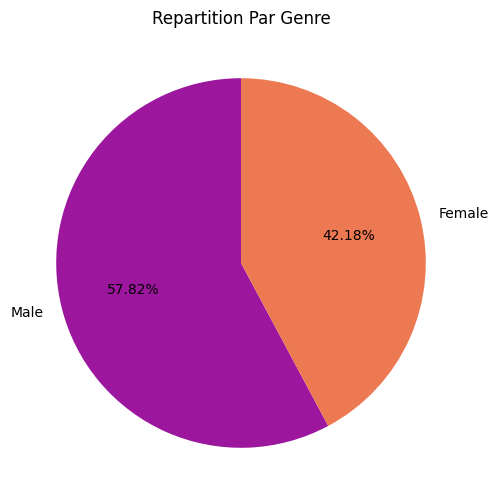

In [74]:
get_pie_repartition_chart(
    series=data["Gender"], title="Repartition Par Genre", palette="plasma"
)

**Interprétation** :  

On remarque une plus grande proportion dans le sexe masculin. 

### 2.3.2 Repartition par Distance depuis la maison

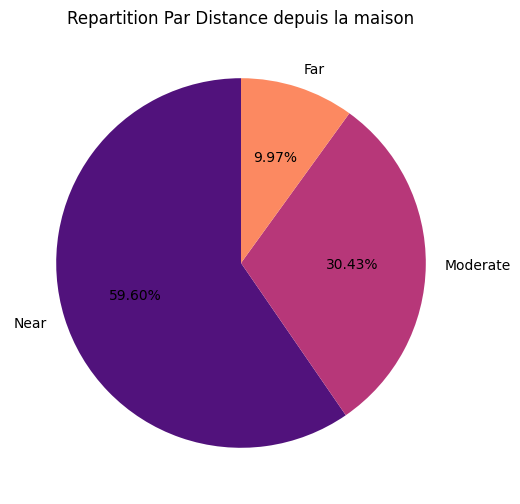

In [75]:
get_pie_repartition_chart(
    series=data["Distance_from_Home"],
    title="Repartition Par Distance depuis la maison",
    palette="magma",
)

**Interprétation** : 

On remarque que plus de la moitié des étudiants habitent pas loin.
Une part significative habite à une distance modérée et une part non négligeable habite loin. 

### 2.3.3 Repartition par Le niveau d'education des parents

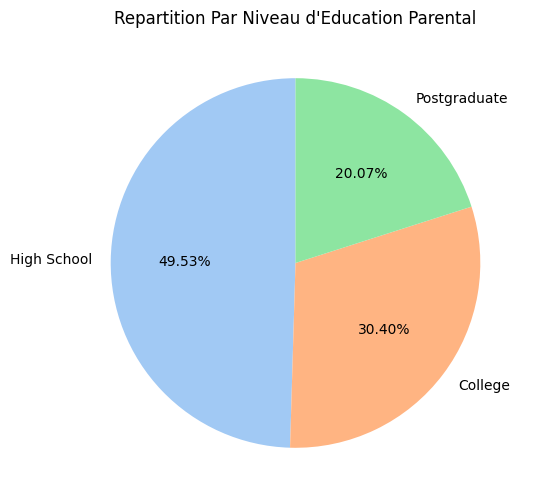

In [76]:
get_pie_repartition_chart(
    series=data["Parental_Education_Level"],
    title="Repartition Par Niveau d'Education Parental",
    palette="pastel",
)

**Interprétation** : 

On remarque que beaucoup de parent se sont arretés au lycée et une part considerable au collège et que peu ont atteri aux études universitaires.

### 2.3.4 Repartition par La présence ou non de difficulté d'apprentissage

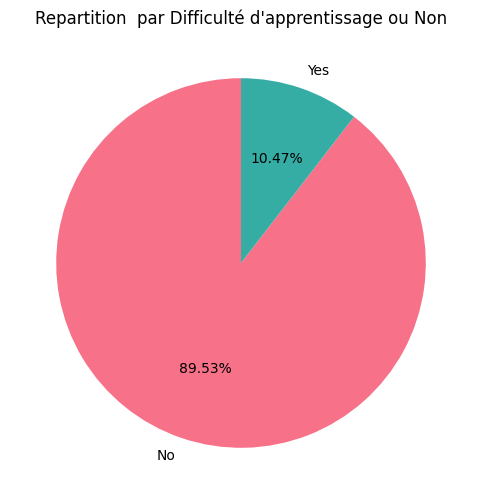

In [77]:
get_pie_repartition_chart(
    series=data["Learning_Disabilities"],
    title="Repartition  par Difficulté d'apprentissage ou Non",
    palette="husl",
)

**Interprétation** : 

On remarque la présence d'une minorité qui a des difficultés d'apprentissage.

### 2.3.5 Repartition par Influence de l'entourage



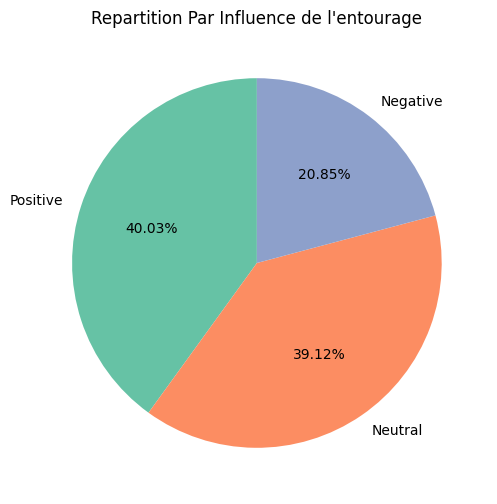

In [78]:
get_pie_repartition_chart(
    series=data["Peer_Influence"],
    title="Repartition Par Influence de l'entourage",
    palette="Set2",
)

**Interprétation** : 
La majorité des étudiants ont un  entourage avec une influence positive , mais une partie aussi conséquente est neutre et une non négligeable est négative.

### 2.3.6 Repartition par Par Implication des parents

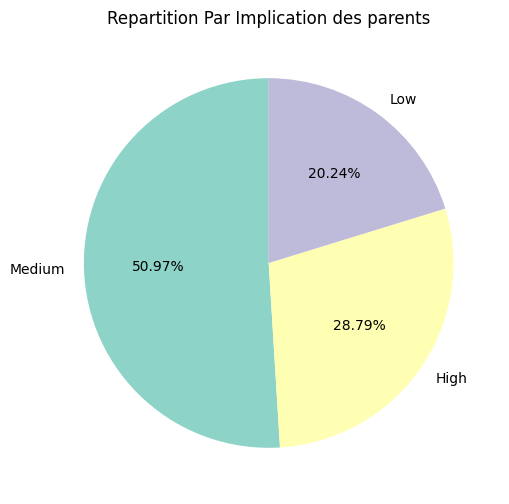

In [79]:
get_pie_repartition_chart(
    series=data["Parental_Involvement"],
    title="Repartition Par Implication des parents",
    palette="Set3",
)

**Interprétation** : 
Plus de la moitié ont leurs parents impliqués et une partie a les parents très impliqués mais une part négligeable a une implication moins présente des parents.

### 2.3.7 Repartition par Par Accès aux ressources

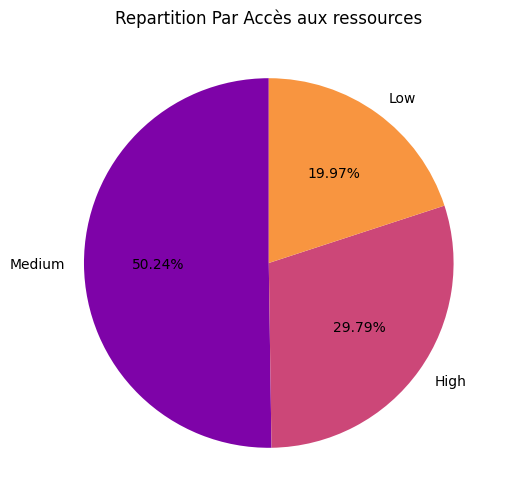

In [80]:
get_pie_repartition_chart(
    series=data["Access_to_Resources"],
    title="Repartition Par Accès aux ressources",
    palette="plasma",
)

**Interprétation** : 
Une part importante à un accès moyen aux ressources et une autre un peu moins à un accès très élevé et on a une minorité avec un accès faible.

### 2.3.8 Repartition par Pratique ou Non d'activités extrascolaires

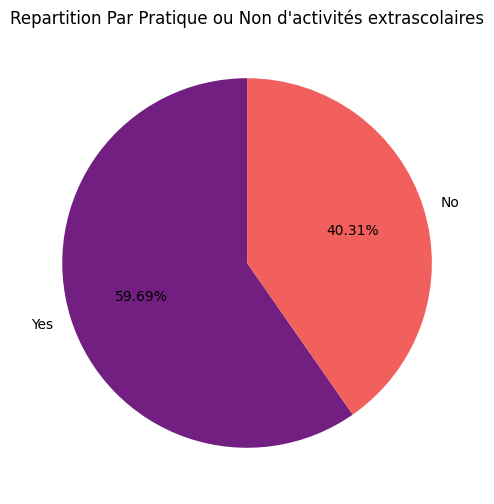

In [81]:
get_pie_repartition_chart(
    series=data["Extracurricular_Activities"],
    title="Repartition Par Pratique ou Non d'activités extrascolaires",
    palette="magma",
)

**Interprétation** : 

Plus de la moitié pratiquenet des activités extrascolaires.

### 2.3.9 Repartition par Niveau de motivation

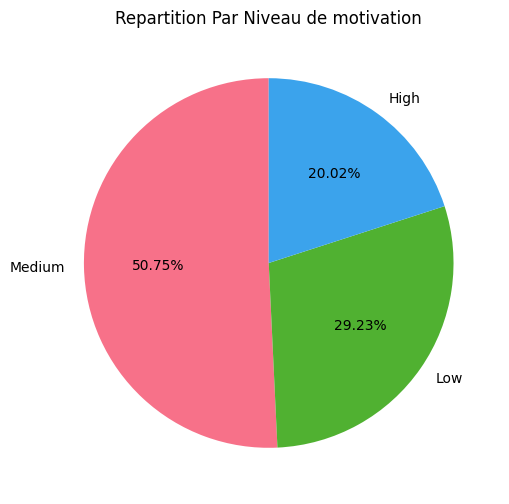

In [82]:
get_pie_repartition_chart(
    series=data["Motivation_Level"],
    title="Repartition Par Niveau de motivation",
    palette="husl",
)

**Interprétation** : 
Plus de la moitié ont un niveau de motivation moyen et une part moins élevée pour un niveau de motivation faible et une part faible à un niveau de motivation élevé.

### 2.3.10 Repartition par Accès à internet

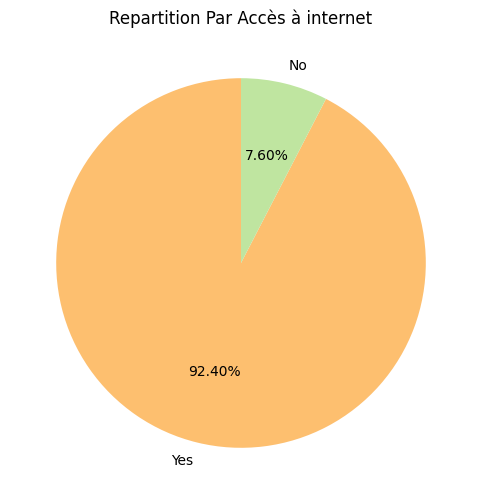

In [83]:
get_pie_repartition_chart(
    series=data["Internet_Access"],
    title="Repartition Par Accès à internet",
    palette="Spectral",
)

**Interprétation** : 
Une majorité des étudiants ont accès à internet , et une  minorité non.

### 2.3.11 Repartition par Niveau de Revenu Familiale

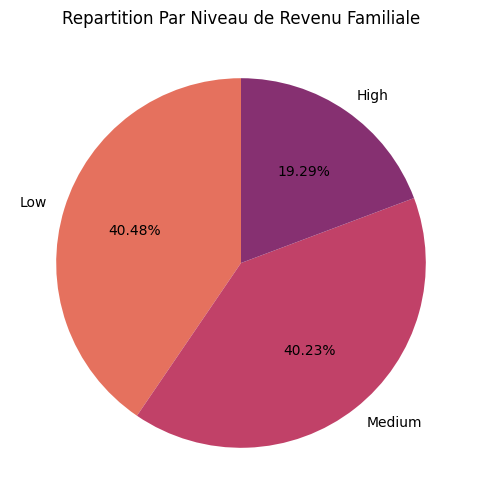

In [84]:
get_pie_repartition_chart(
    series=data["Family_Income"],
    title="Repartition Par Niveau de Revenu Familiale",
    palette="flare",
)

**Interprétation** : 
On a deux grand groupes : l'un pour les étudiants avec un revenu familiale faible et l'autre avec un revenu  modéré . Ensuite on a une minorité aisé.

### 2.3.12 Repartition par Par Niveau de Qualité du Professeur

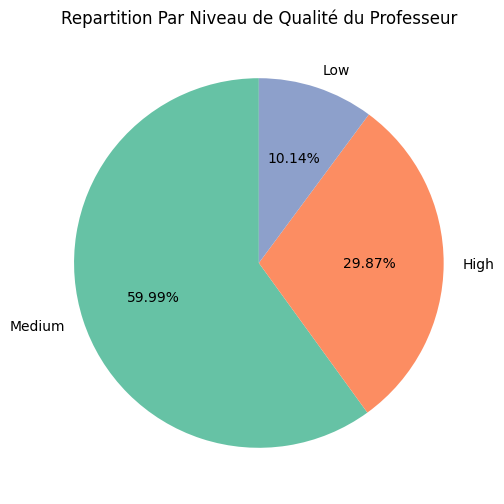

In [85]:
get_pie_repartition_chart(
    series=data["Teacher_Quality"],
    title="Repartition Par Niveau de Qualité du Professeur",
    palette="Set2",
)

**Interprétation** : 
La plupart des étudiants ont des  professeurs de qualité moyenne et une autre proportion moins représentée a des très professeurs et une faible proportion des professeurs avec un niveau médiocre.

### 2.3.13 Repartition par Type d'Université

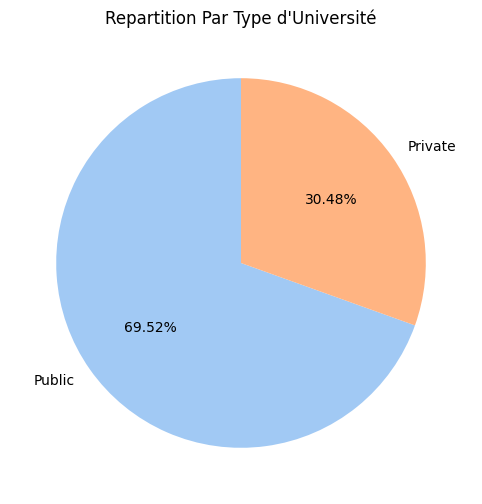

In [86]:
get_pie_repartition_chart(
    series=data["School_Type"],
    title="Repartition Par Type d'Université",
    palette="pastel",
)

**Interprétation** : 
Il y a significativement plus d'etudiants dans des universités plubliques que privés.

### 2.3.14 Distribution des scores de l'examen

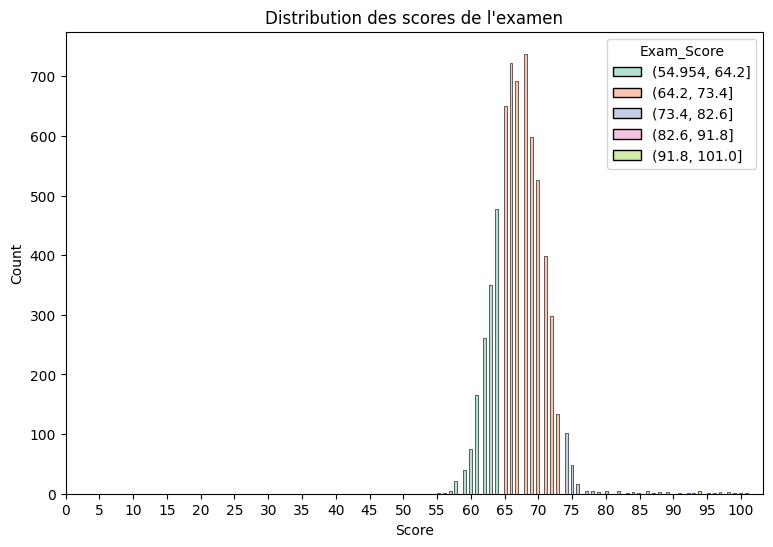

In [87]:
plt.figure(figsize=(9,6))

bins = pd.cut(data["Exam_Score"],bins=5)

sns.histplot(data=data,x="Exam_Score",hue=bins,palette="Set2")

plt.xticks(ticks=[i*5 for i in range(21)])

plt.xlabel("Score")
plt.title("Distribution des scores de l'examen")

plt.show()

**Interprétation** : 
On remarque que la majorité des valeurs se situent entre 65 et 75 . 

### 2.3.14 Distribution des scores de l'examen précédent

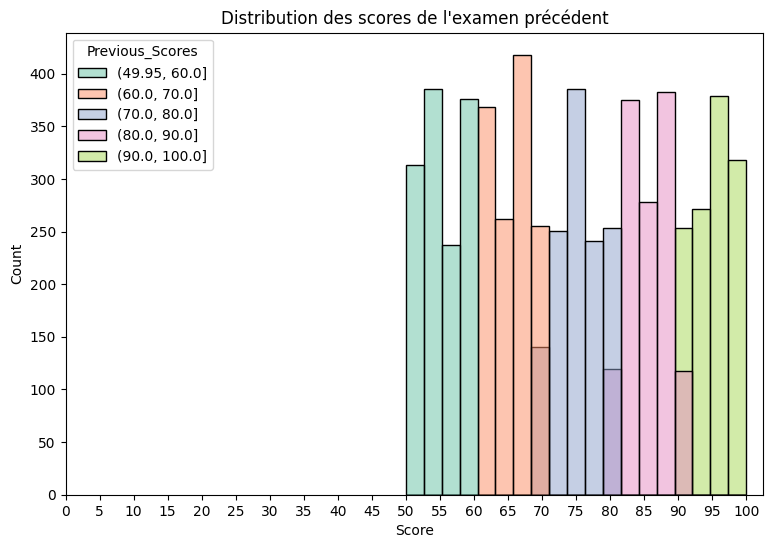

In [88]:
plt.figure(figsize=(9, 6))

bins = pd.cut(data["Previous_Scores"], bins=5)

sns.histplot(data=data, x="Previous_Scores", hue=bins, palette="Set2")

plt.xticks(ticks=[i * 5 for i in range(21)])

plt.xlabel("Score")
plt.title("Distribution des scores de l'examen précédent")

plt.show()

**Interprétation** : 
Les scores de l'examen précedent sont bien plus repartis avec un minimum plus bas mais aussi plus de bonne notes. 

## 2.4 Analyse Bivariée

In [89]:
# On recueille la liste des variables numériques
features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score",
]

In [90]:
# Cette fonction retourne 7 scatters plots
def get_scatters(data:pd.DataFrame,col_list:list[str],x_col:str):
    """_summary_

    Args:
        data (pd.DataFrame): la dataframe
        col_list (list[str]): la liste des colonnes
        x_col (str): la colonne en absisse
    """

    # Initialisation de la figure et des axes
    fig,axes= plt.subplots(2,4,figsize=(20,10))

    # Applatissement des axes pour faciliter l'iteration
    axes_plats = axes.flatten()

    # Iteration sur chaque colonne et son indice
    for i,col_name in enumerate(col_list):
        # Récuperation de l'axe courant
        ax=axes_plats[i]

        # Scatterplot
        sns.scatterplot(data=data,x=x_col,y=col_name,ax=ax)

        # Titre du graphique
        ax.set_title(f"{x_col} vs {col_name}")

    # Masquage du dernier graphique vide
    if len(col_list)<len(axes_plats):
        axes_plats[-1].axis('off')

    # Evite le chevauchement des titres
    plt.tight_layout()

    # Affichage du graphique
    plt.show()

### 2.4.1 Nuages de point pour Exam_Score

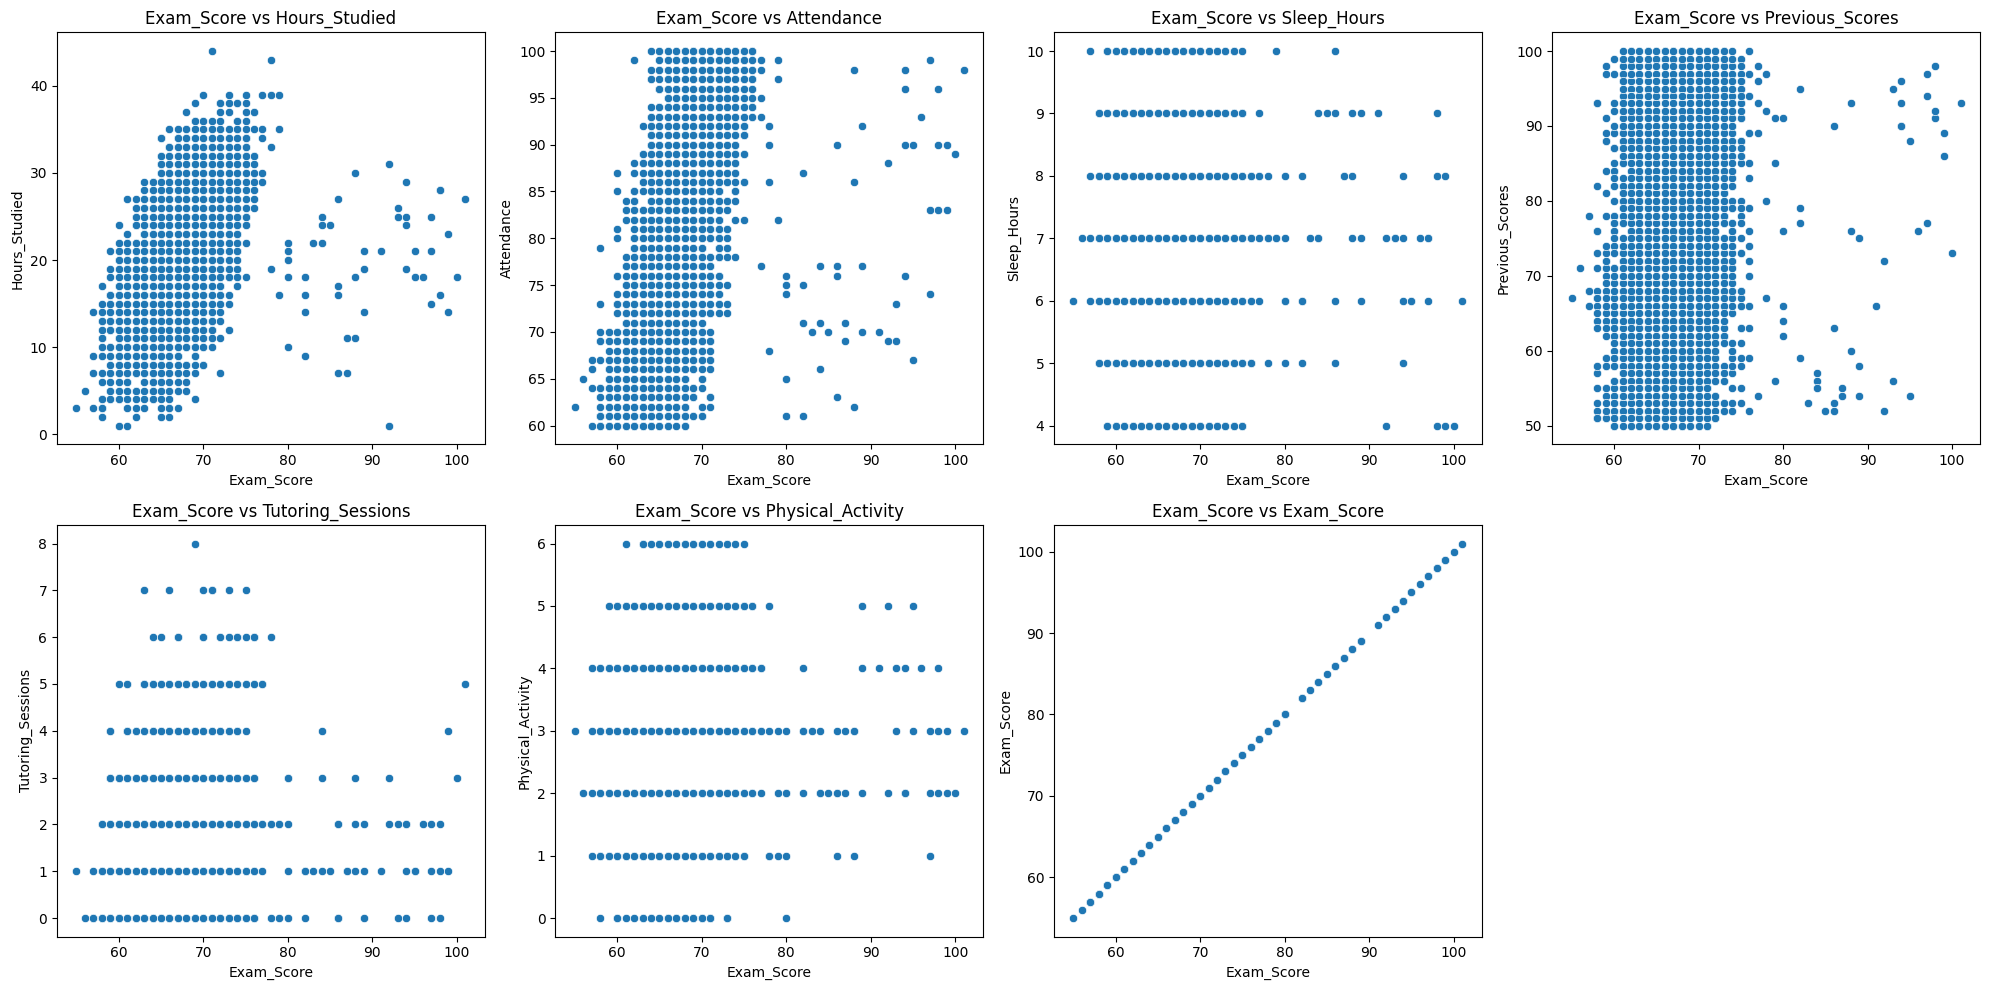

In [91]:
get_scatters(data=data,x_col='Exam_Score',col_list=features)

**Interprétation** : 

Il semble y avoir une corrélation entre le score de l'examen et le nombre d'heures passé à étudier et une légère tendance avec l'assiduité.

### 2.4.2 Nuages de point pour Previous_Scores

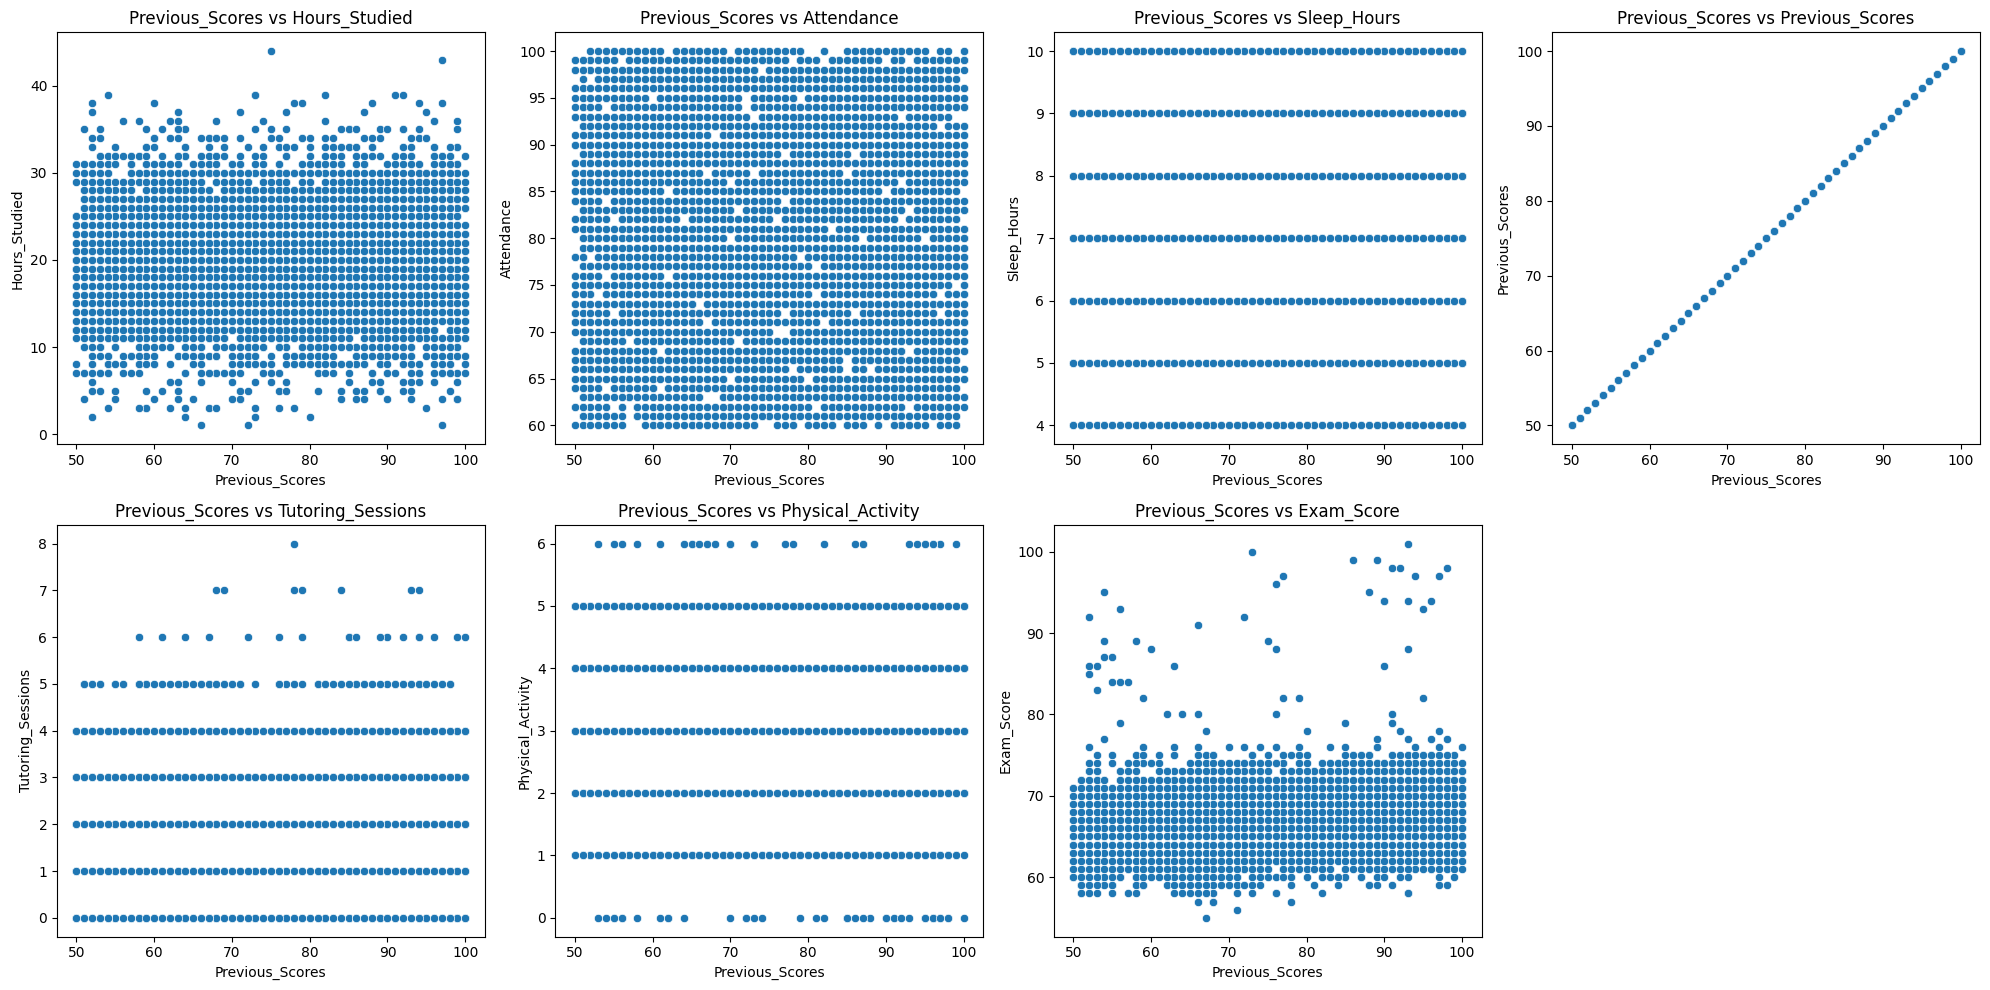

In [92]:
get_scatters(data=data, x_col="Previous_Scores", col_list=features)

**Interprétation** : 
Absence de corrélations.

### 2.4.3 Nuages de point pour Attendance

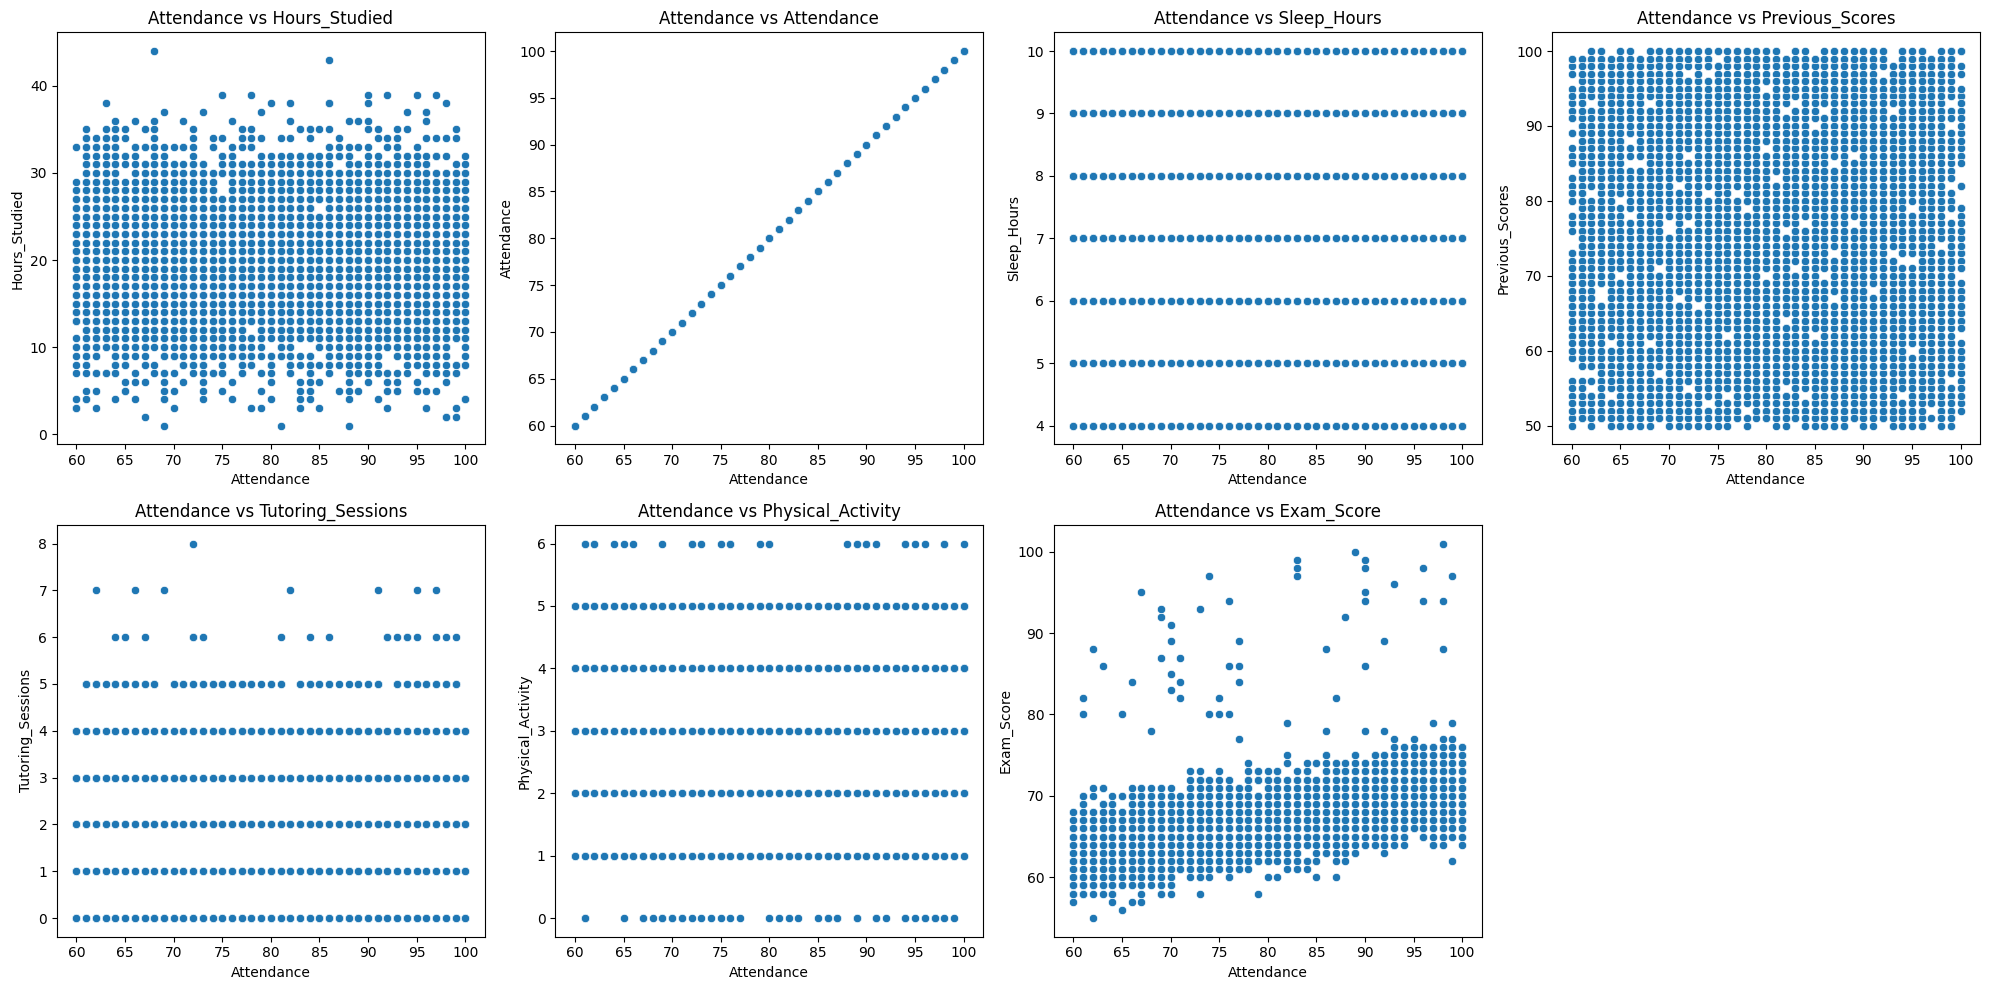

In [93]:
get_scatters(data=data, x_col="Attendance", col_list=features)

**Interprétation** : 
Corrélation avec le score de l'examen.

### 2.4.4 Nuages de point pour Hours_Studied

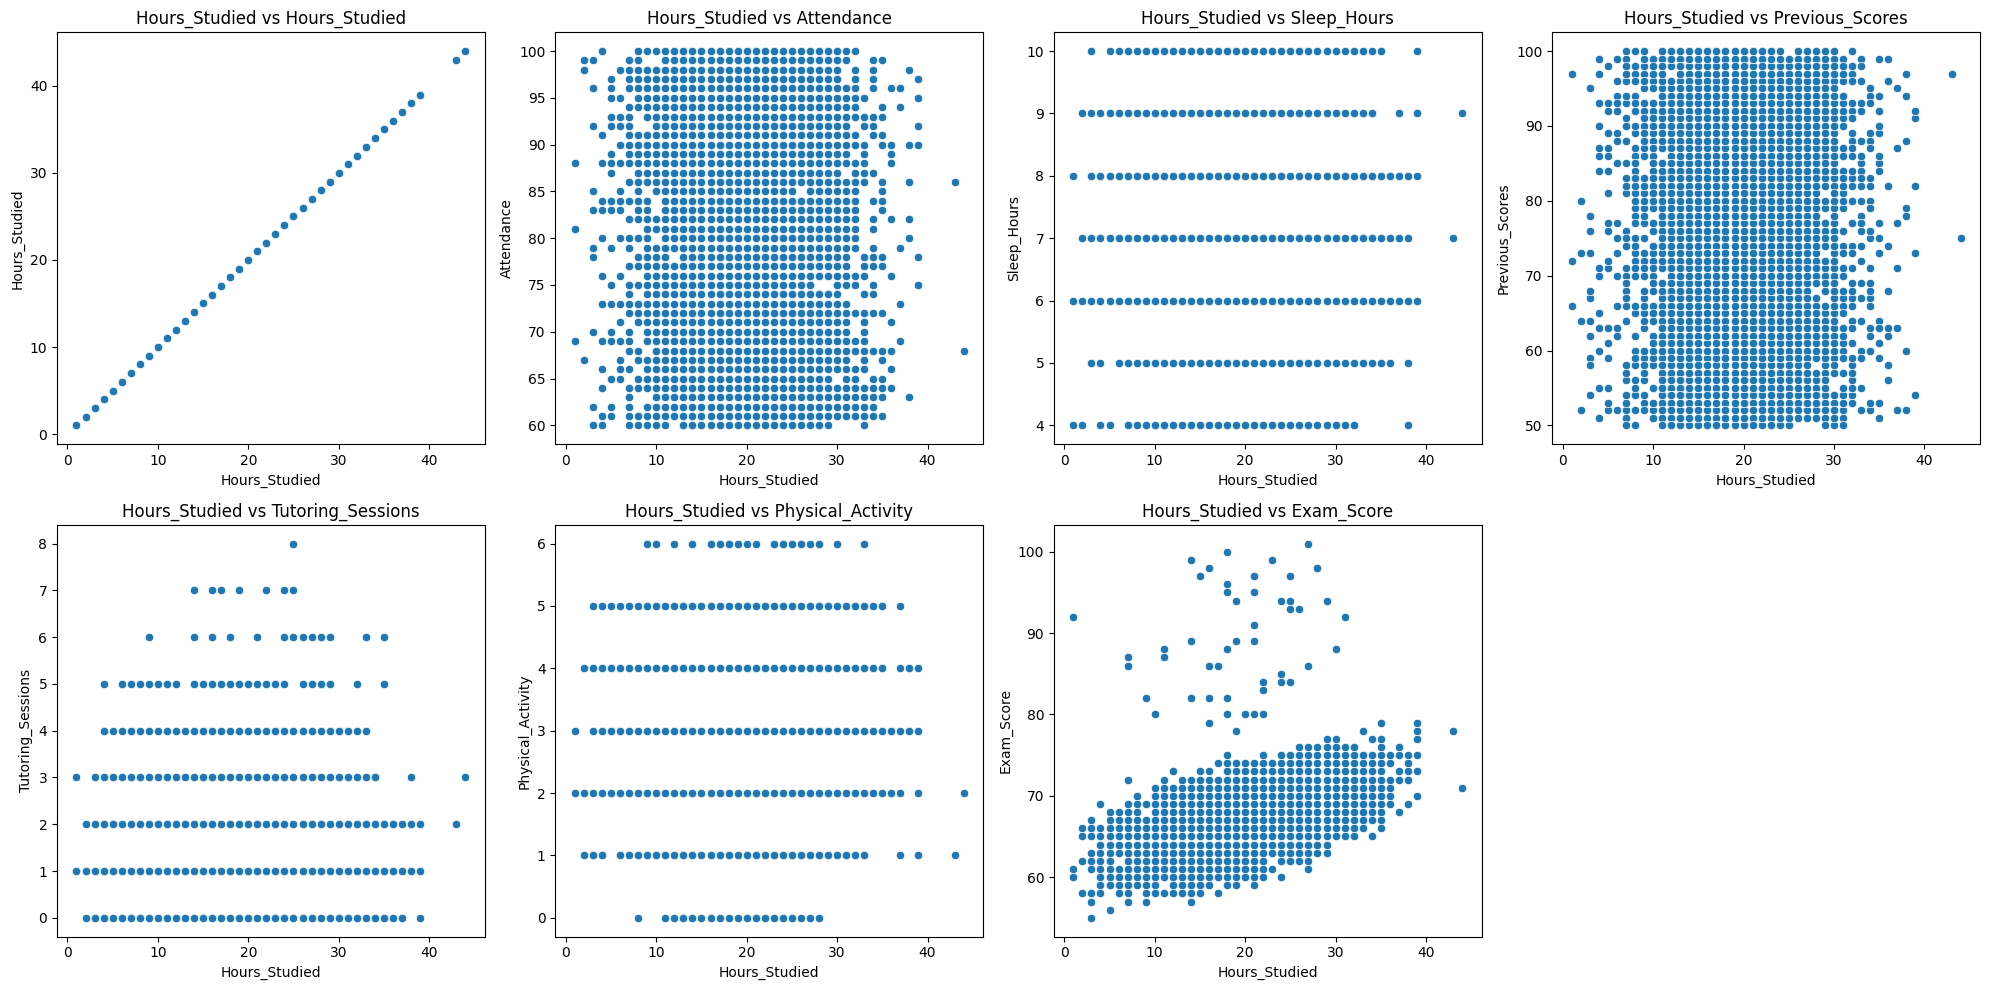

In [94]:
get_scatters(data=data, x_col="Hours_Studied", col_list=features)

**Interprétation** : 

Il semble y avoir une corrélation entre le score de l'examen et le nombre d'heures passé à étudier .

### 2.4.5 Nuages de point pour Sleep_Hours

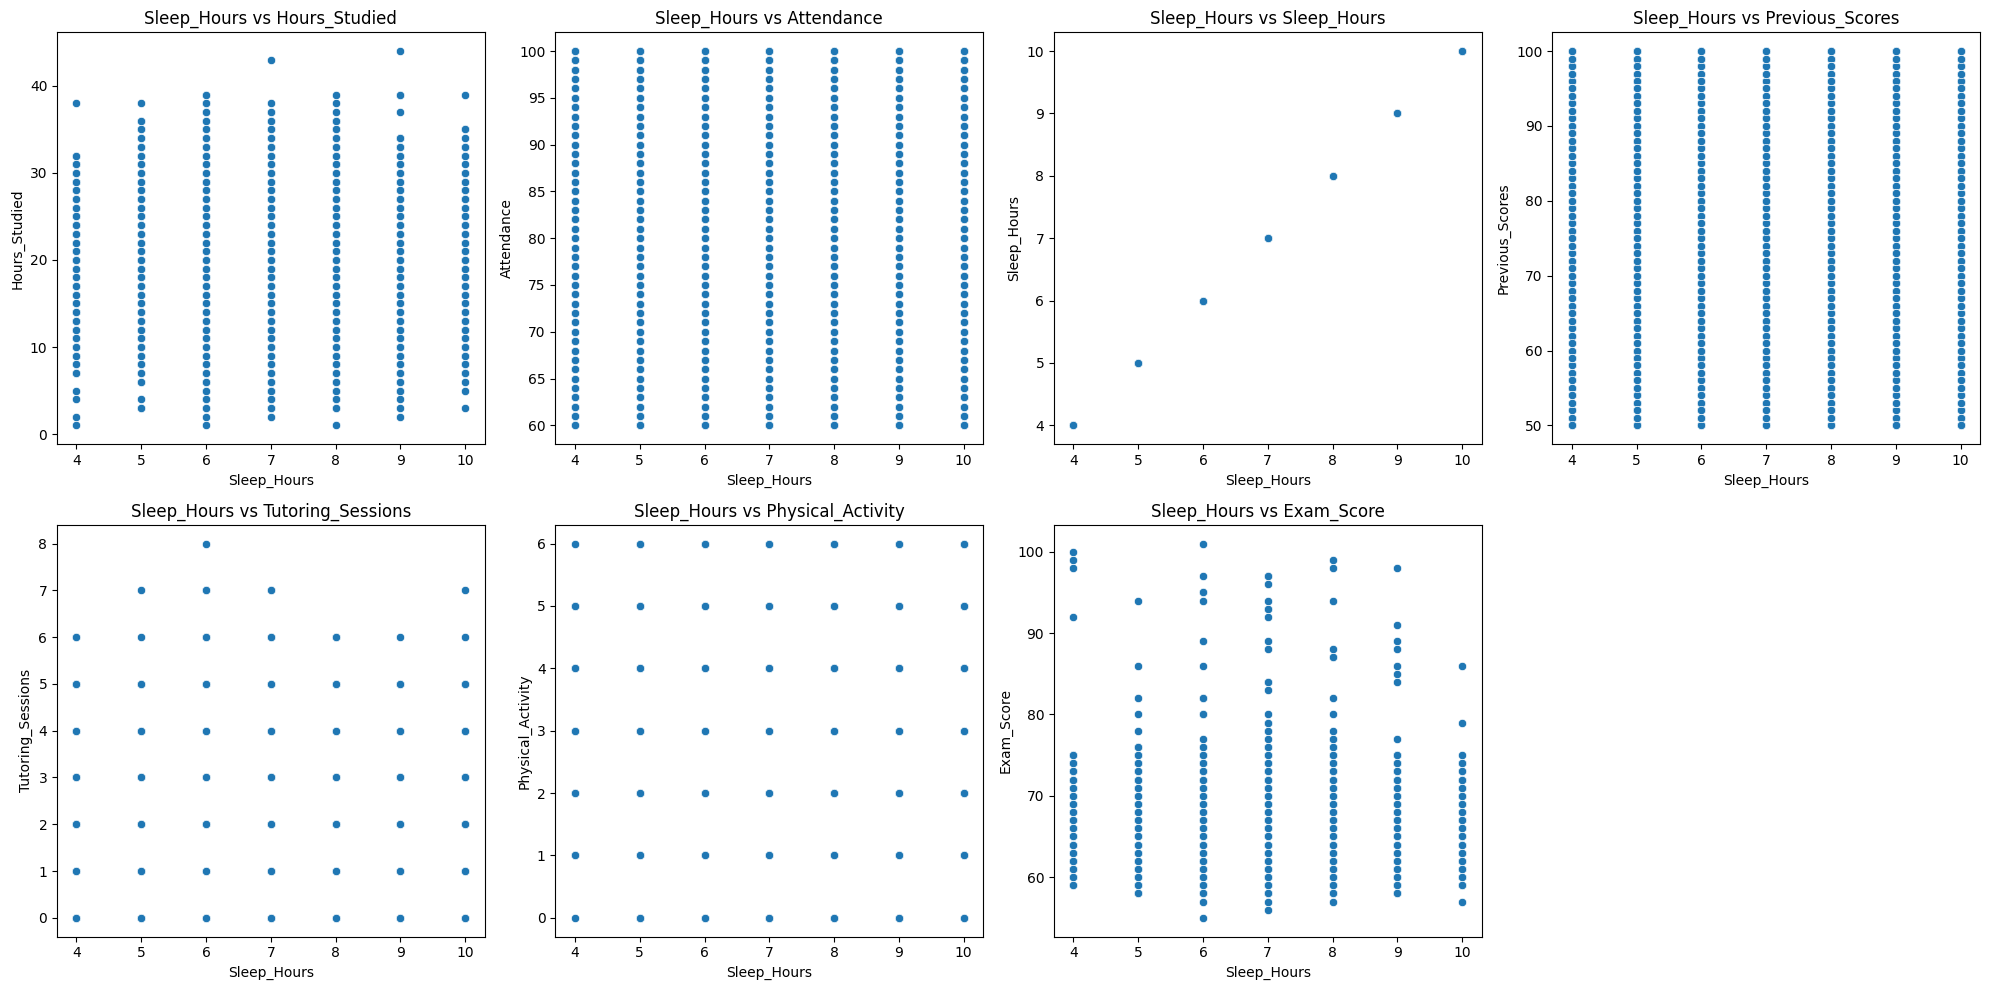

In [95]:
get_scatters(data=data, x_col="Sleep_Hours", col_list=features)

**Interprétation** : 

Absence de corrélations.

### 2.4.6 Nuages de point pour Tutoring_Sessions

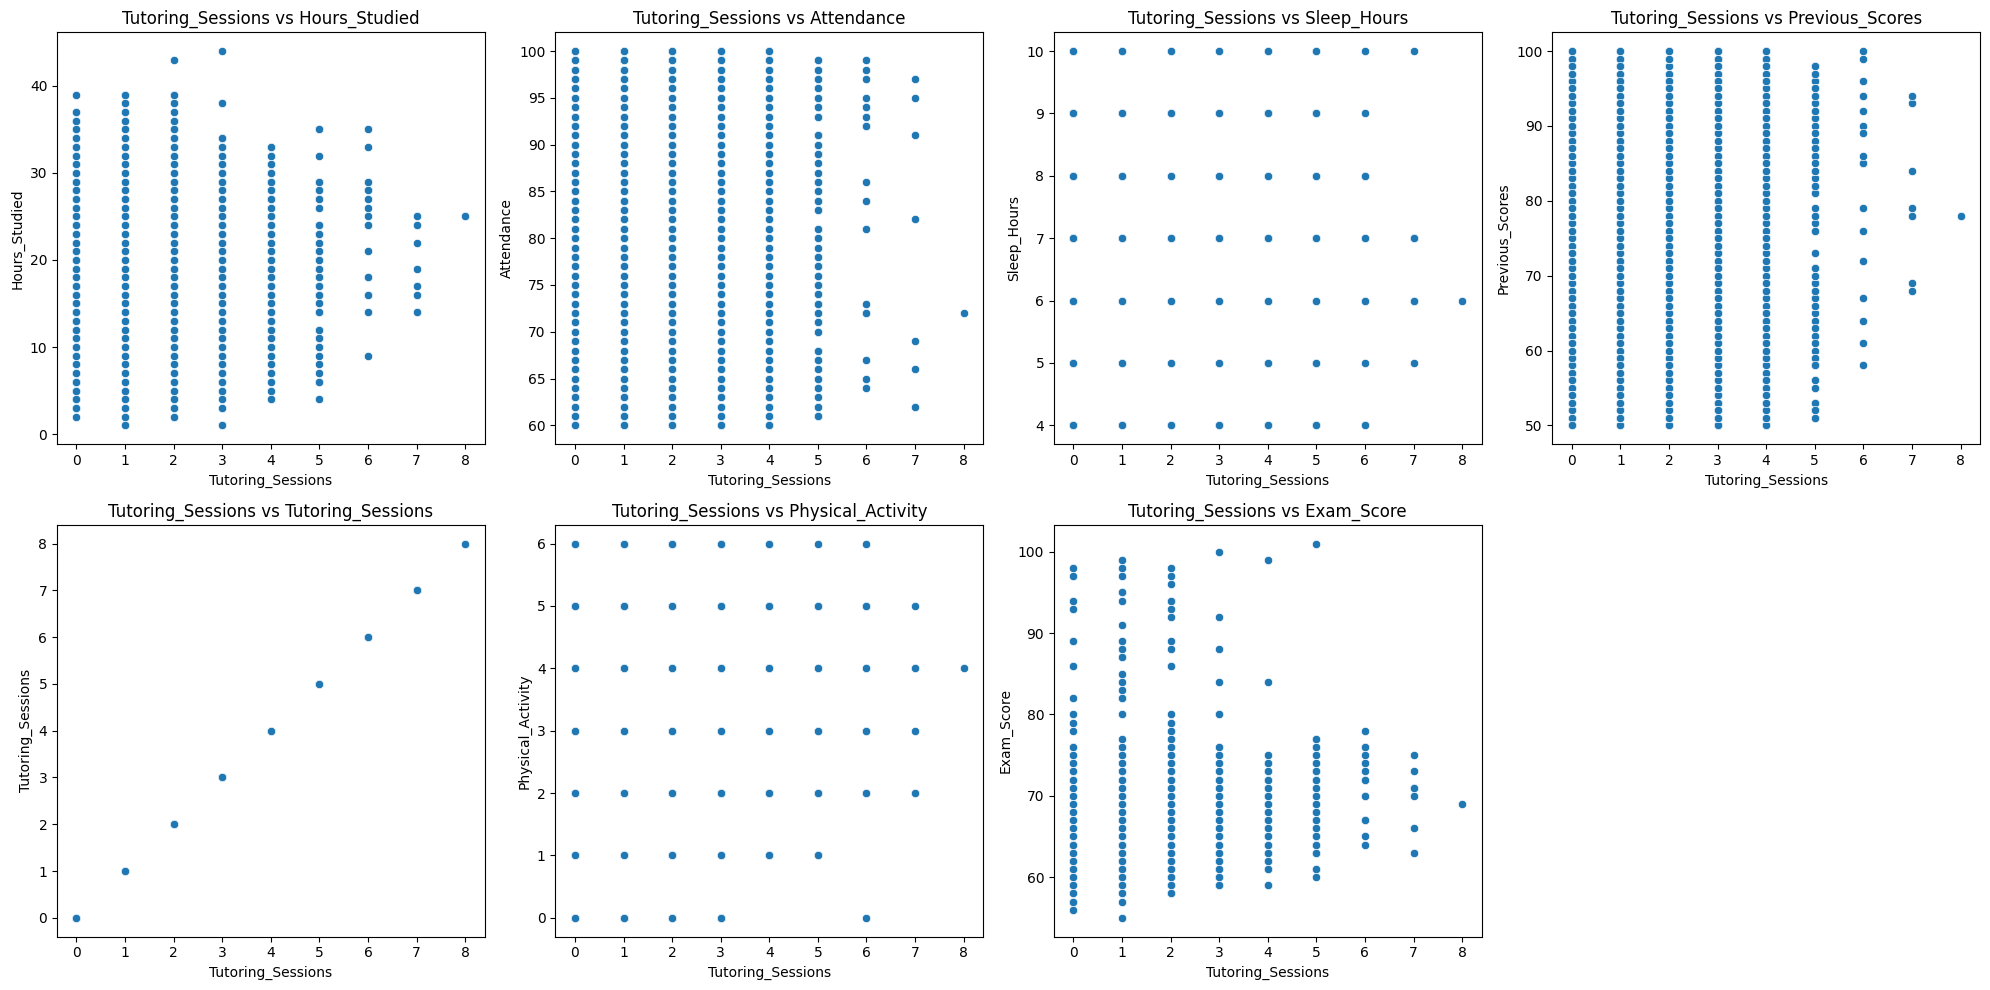

In [96]:
get_scatters(data=data, x_col="Tutoring_Sessions", col_list=features)

**Interprétation** : 

Absence de corrélations.

### 2.4.7 Nuages de point pour Physical_Activity

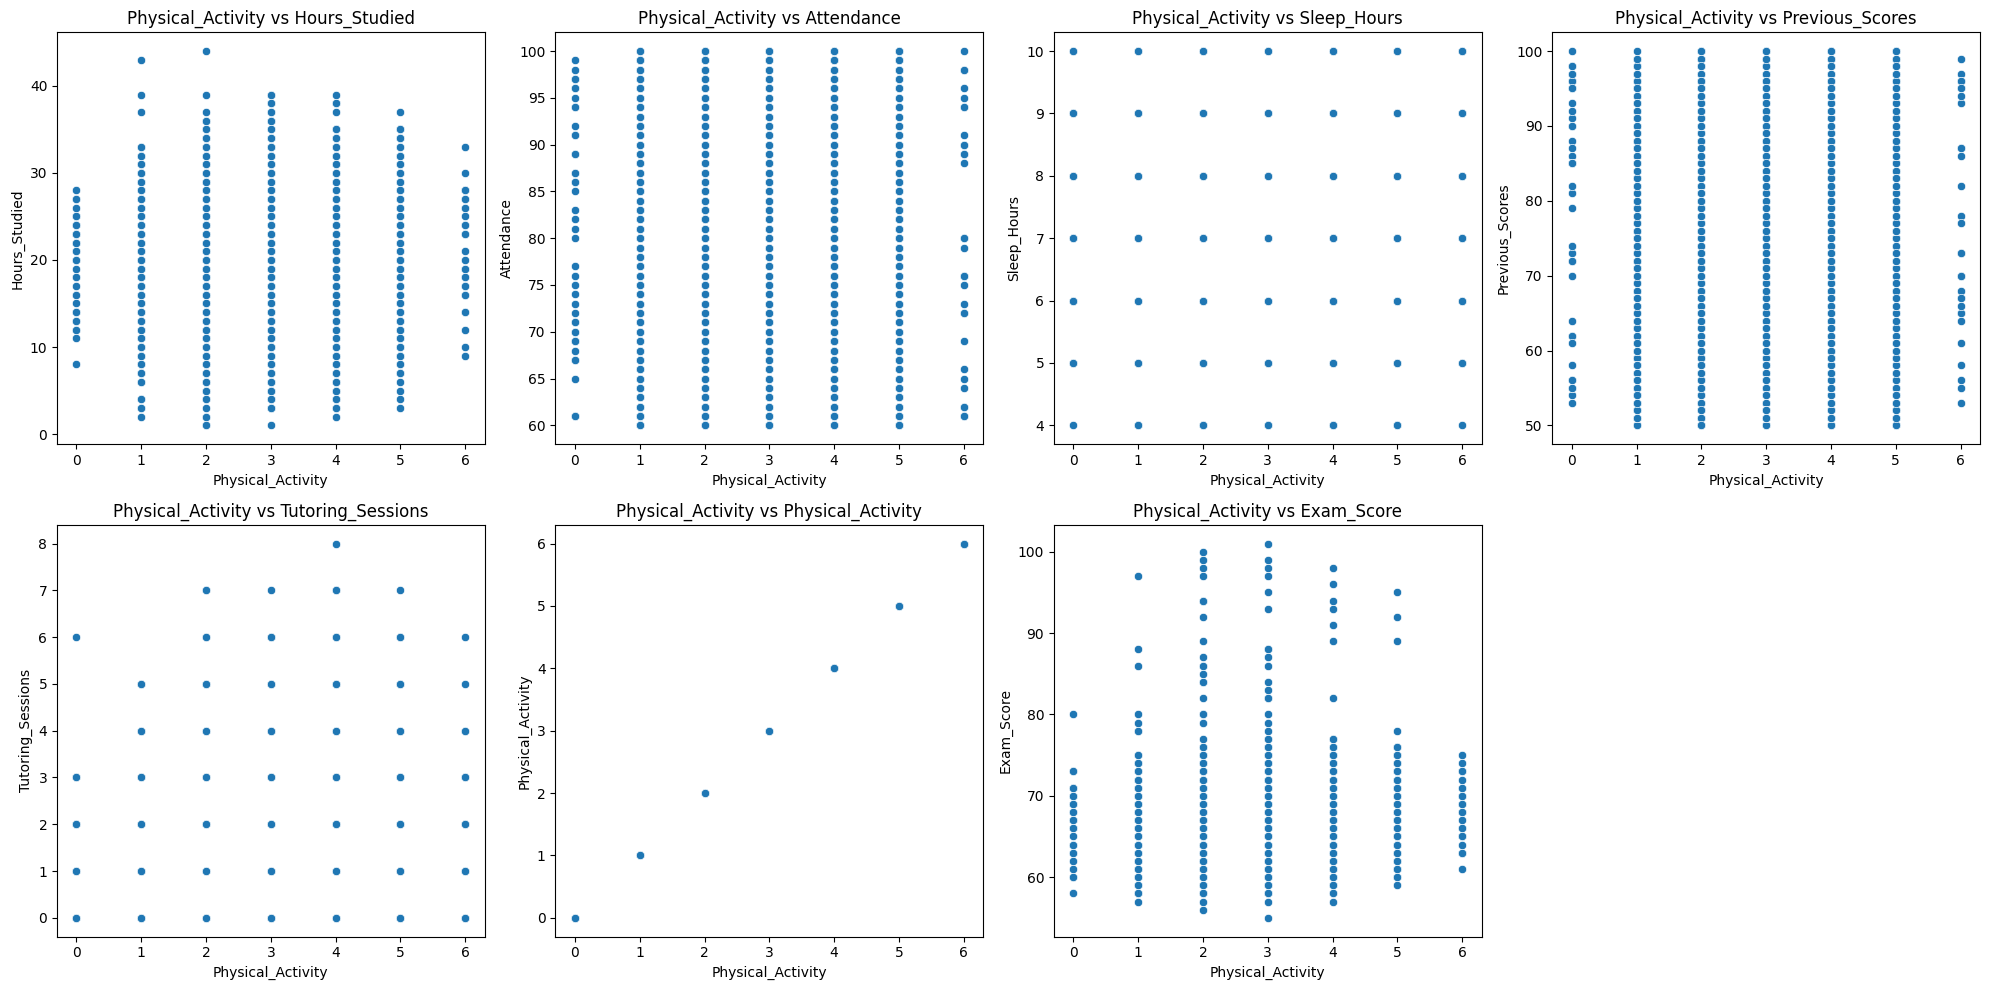

In [97]:
get_scatters(data=data, x_col="Physical_Activity", col_list=features)

**Interprétation** : 

Absence de corrélations.

### 2.4.8 Tableau de corrélation

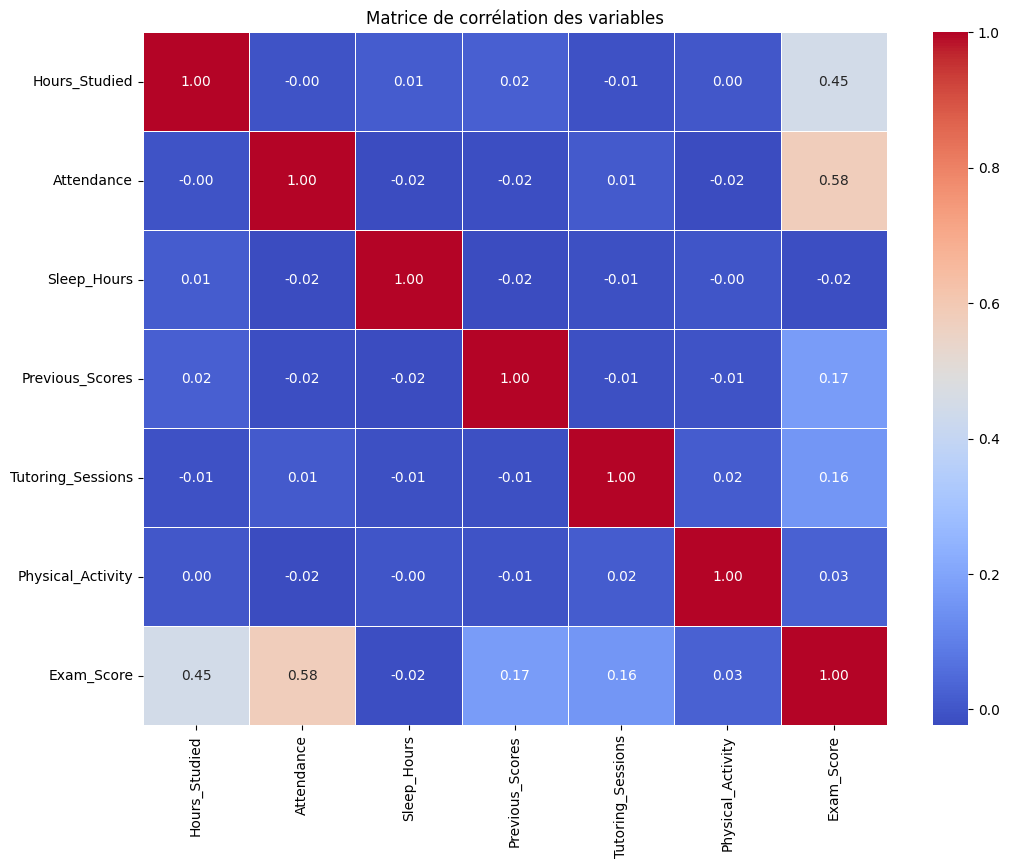

In [98]:
# Calcul de la matrice
corr_matrix = data.corr(numeric_only=True)

# Initialisation de la figure
plt.figure(figsize=(12,9))

# La heatmap
sns.heatmap(data=corr_matrix,cmap="coolwarm",annot=True,fmt=".2f",linewidths=0.5)

# Le titre du graphique
plt.title("Matrice de corrélation des variables")

# Affichage du graphique
plt.show()

**Interprétation** : 
L'assiduté (Attendance) et le score à l'examen(Exam_Score) sont corrélés et Hours_Studied et Exam_score sont légerement corrélés.

# 3. Reduction de dimension et segmentation
On va faire ACP et clustering .

## 3.1 Sélection des variables quantitatives

In [99]:
# On obtient un nouveau dataframe df avec les variables numériques
df = data[features]

# Affichage d'un extrait de df
df.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,23,84,7,73,0,3,67
1,19,64,8,59,2,4,61
2,24,98,7,91,2,4,74
3,29,89,8,98,1,4,71
4,19,92,6,65,3,4,70


## 3.2 Standarisation   
Ici on va standariser les données.

In [100]:
# Ici on a la matrice des données X
X = df.values

# Affichage d'un extrait de X
X[:5]

array([[23, 84,  7, 73,  0,  3, 67],
       [19, 64,  8, 59,  2,  4, 61],
       [24, 98,  7, 91,  2,  4, 74],
       [29, 89,  8, 98,  1,  4, 71],
       [19, 92,  6, 65,  3,  4, 70]])

In [101]:
# Instancions notre scaler
scaler = StandardScaler()

# Ici on a la matrice centrée et réduite
X_Scaled = scaler.fit_transform(X)

In [102]:
# Verification de la standarisation
pd.DataFrame(X_Scaled).describe().round().loc[['mean','std']]

,0,1,2,3,4,5,6
mean,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3.3 PCA

In [103]:
# Choix du nombre de composantes
n_components = 5

# Instanciation de PCA
pca = PCA(n_components=n_components)

# On entraine notre PCA
pca.fit(X_Scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",5
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

### 3.3.1 Variance expliquée et scree plot
On va maintenant s'interesser à la variance expliquée par chacune de nos composantes.

In [104]:
# Variance expliquée par chaque composante
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"Composante {i+1} - {v:.2%}% de variance expliquée")

Composante 1 - 25.24%% de variance expliquée
Composante 2 - 14.89%% de variance expliquée
Composante 3 - 14.58%% de variance expliquée
Composante 4 - 14.56%% de variance expliquée
Composante 5 - 13.89%% de variance expliquée


In [105]:
# Enregistrons les variances expliquées dans une variable
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([25.24, 14.89, 14.58, 14.56, 13.89])

In [106]:
# Calcul de la somme cumulée des variances
scree_cum = np.cumsum(scree).round()
scree_cum

array([25., 40., 55., 69., 83.])

Avec les 4 premières composantes on a environ 70% de la variance.

On va créer une liste qui va nous servir de label pour nos composantes.

In [107]:
x_list = [str(i+1) for i in range(n_components)]
x_list

['1', '2', '3', '4', '5']

On va maintenant réaliser le graphique de l'éboulis des valeurs prorpres

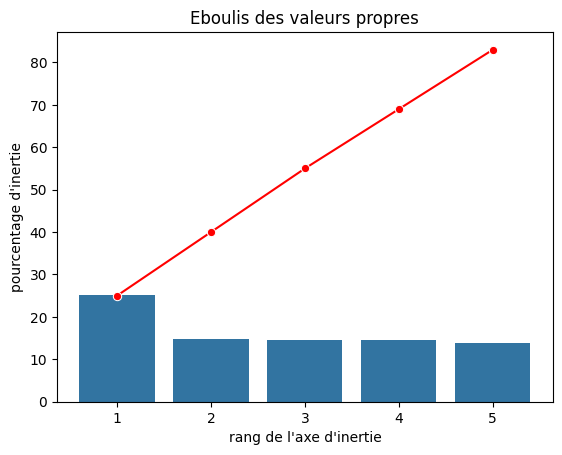

In [108]:
# Diagramme à barre des variances expliquées par chaque composante
sns.barplot(x=x_list,y=scree)

# Courbe de la variance expliquée cumumulée
sns.lineplot(x=x_list,y=scree_cum,color="red",marker="o")

# Labels des axes
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")

# Titre du graphique
plt.title("Eboulis des valeurs propres")

# Affichage du graphique
plt.show()

### 3.3.2 Composantes
Interessons nous maintenant aux composantes

In [109]:
# Recuperation des composantes
pcs = pca.components_
pcs

array([[ 0.40997195,  0.53221844, -0.02948951,  0.15872918,  0.14600623,
         0.01080988,  0.70793169],
       [ 0.5430868 , -0.44775605,  0.2059943 ,  0.51794837, -0.43976998,
         0.0210966 ,  0.00493822],
       [ 0.25944583, -0.21718905,  0.43413303, -0.3346353 ,  0.38271324,
         0.66204415,  0.01710635],
       [ 0.08833569,  0.19792437,  0.66431196, -0.45290008, -0.3357322 ,
        -0.44028447,  0.00523067],
       [ 0.02906102, -0.26230493,  0.25530938,  0.26528018,  0.7089875 ,
        -0.54045378, -0.00644665]])

In [110]:
# Transformation en dataframe
pcs = pd.DataFrame(pcs)

# Affichage d'un extrait
pcs

,0,1,2,3,4,5,6
0,0.409972,0.532218,-0.029490,0.158729,0.146006,0.010810,0.707932
1,0.543087,-0.447756,0.205994,0.517948,-0.439770,0.021097,0.004938
2,0.259446,-0.217189,0.434133,-0.334635,0.382713,0.662044,0.017106
3,0.088336,0.197924,0.664312,-0.452900,-0.335732,-0.440284,0.005231
4,0.029061,-0.262305,0.255309,0.265280,0.708987,-0.540454,-0.006447


In [111]:
pcs.columns=features
pcs.index=[f"F{x}" for x in x_list]
pcs

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
F1,0.409972,0.532218,-0.029490,0.158729,0.146006,0.010810,0.707932
F2,0.543087,-0.447756,0.205994,0.517948,-0.439770,0.021097,0.004938
F3,0.259446,-0.217189,0.434133,-0.334635,0.382713,0.662044,0.017106
F4,0.088336,0.197924,0.664312,-0.452900,-0.335732,-0.440284,0.005231
F5,0.029061,-0.262305,0.255309,0.265280,0.708987,-0.540454,-0.006447


### 3.3.3 Représentation visuelle

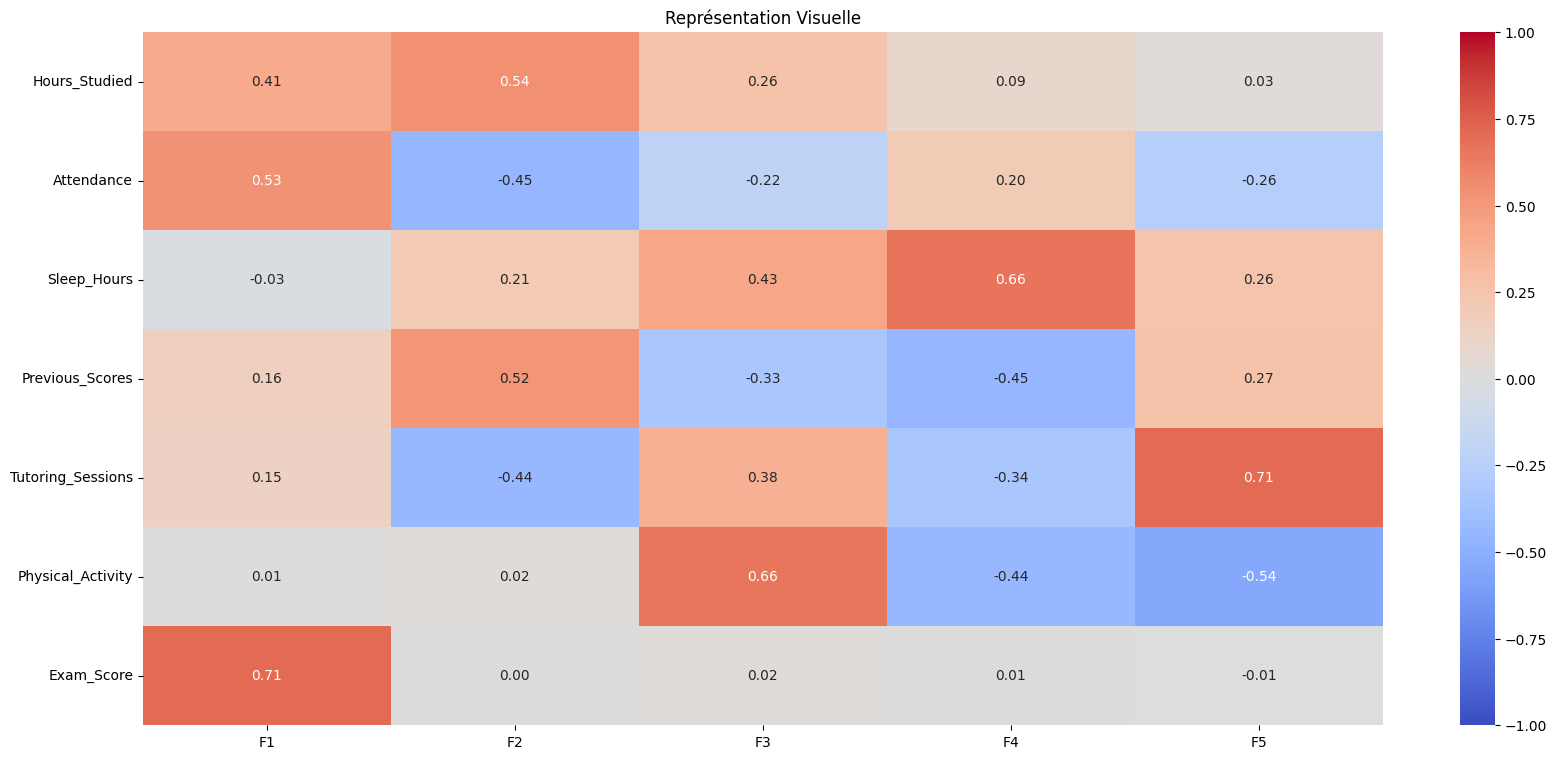

In [112]:
plt.figure(figsize=(20,9))

sns.heatmap(data=pcs.T,vmin=-1,vmax=1,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Représentation Visuelle")

plt.show()

**Interprétation** : 

- F1 est très corrélé à Exam_Score , corrélé à Attendance et Hours_Studied et faiblement corrélés /décorrélés aux autres variables;

- F2 est corrélé à Previous_Score et Hours_Studied mais décorrélé à Attendance et Tutoring_Session et faiblement corrélés /décorrélés aux autres variables;

- F3 est corrélé avec Physical_Activity , un peu moins à Sleep_Hours et Tutoring_Session et faiblement corrélés /décorrélés aux autres variables;

- F4 est très corrélé à Sleep_Hours et un peu décorrélé à Previous_Score ,  Physical_Activity , Tutoring_Session et faiblement corrélés /décorrélés aux autres variables;


## 3.4 Graphe de corrélations

In [113]:
# Cette fonction retrourne le graphe des corrélations
def correlations_graph(x_y:tuple,features:list[str],pcs:pd.DataFrame,scree:list[float]):
    """_summary_

    Args:
        x_y (tuple): les axes
        features (list[str]): les features
        pcs (pd.DataFrame): le dataframe des composantes
        scree (list[float]): les variances expliquées
    """


    # Initialisation des axes des composantes
    x,y = x_y

    # Initialisation des graphiques
    fig,ax = plt.subplots(figsize=(12,9))

    # Itération sur chaque feature
    for i in range (len(features)) :
        # Dessin de la flêche qui commence à (0,0)
        # dx coordonnée sur PC1 pour feature i
        # dy coordonnée sur PC2 pour feature i
        dx=pcs.iloc[x,i]
        dy=pcs.iloc[y,i]
        ax.arrow(0,0,dx=dx,dy=dy,head_width=0.05,head_length=0.05,width=0.005)

        # Nom de feature
        ax.text(x=dx+0.05,y=dy+0.05,s=features[i])

    # Les axes (absisses,ordonnées)
    plt.plot([-1,1],[0,0],linestyle='--',color='grey')
    plt.plot([0, 0], [-1,1], linestyle="--", color="grey")

    # Le cercle
    # Définissons les points du cercles partant de 0 à 2 pi.
    theta = np.linspace(0,np.pi*2,100)

    # Rayon du cercle
    r=1

    # Tracé du cercle
    xaxis=r*np.cos(theta)
    yaxis=r*np.sin(theta)
    plt.plot(xaxis,yaxis)

    # Labels des axes
    ax.set_xlabel(f"F{y+1} ({scree[y]}%)")
    ax.set_ylabel(f"F{x+1} ({scree[x]}%)")

    # Pour garder la forme circulaire ronde
    ax.axis('equal')

    # Titre du graphique
    plt.title(f"Graphe des corrélations de F{x+1} et F{y+1}")

    # Affichage du graphique
    plt.show()

### 3.4.1 Graphe de corrélations de F1 et F2

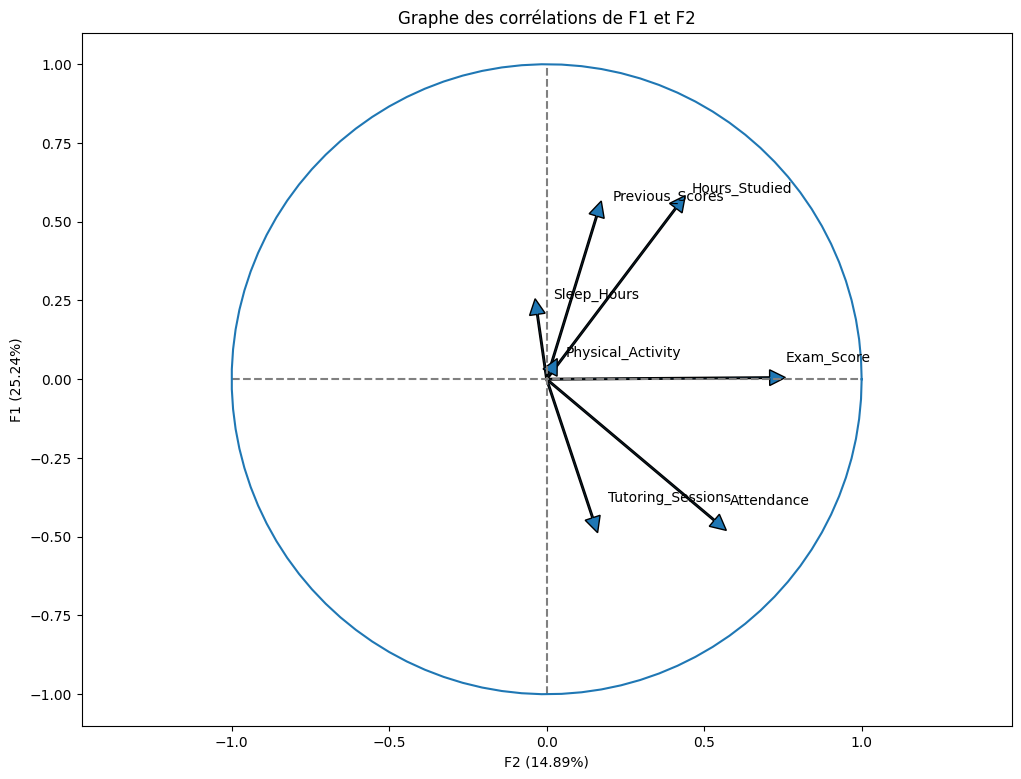

In [114]:
# Choix des axes de PC1 et PC2
x_y=(0,1)
correlations_graph(x_y=x_y,features=features,pcs=pcs,scree=scree)

### 3.4.1 Graphe de corrélations de F3 et F4

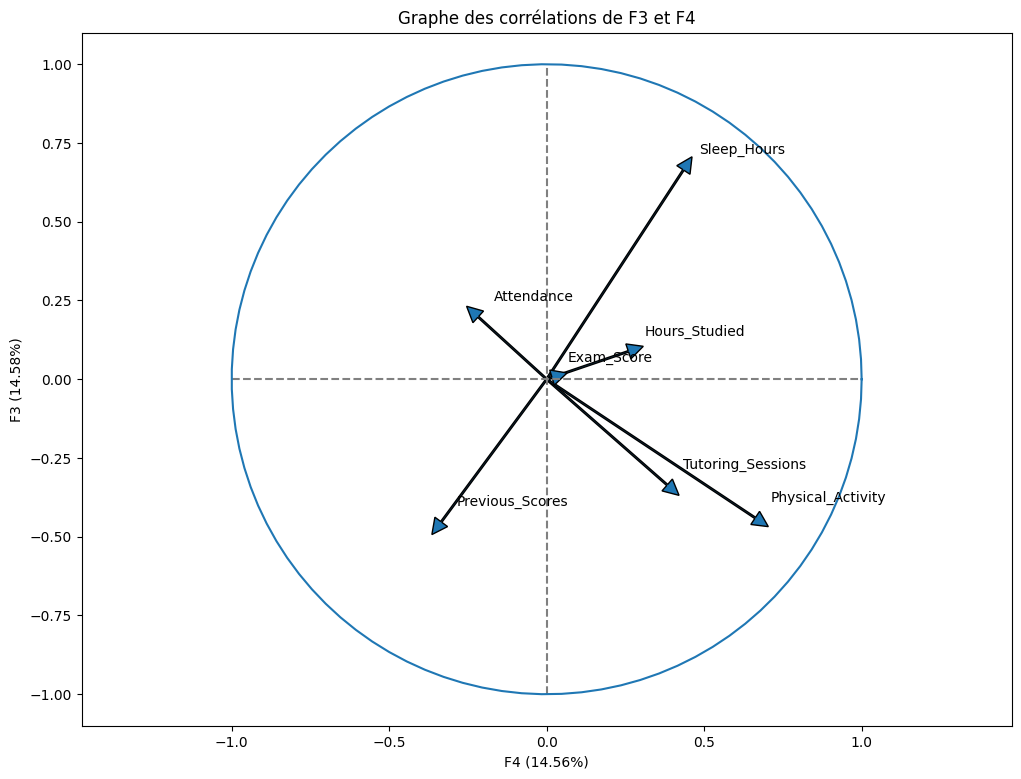

In [115]:
# Choix des axes de PC3 et PC4
x_y = (2, 3)
correlations_graph(x_y=x_y, features=features, pcs=pcs, scree=scree)

## 3.5 Clustering

### 3.5.1 Choix du nombre de cluster

Ici on va choisir le nombre de clusters en faisant un graphique de l'inertie en fonction du nombre de clusters

In [133]:
# Liste vide pour enregistrer les inerties
inertia_list=[]

# liste du nombre de clusters
k_list = list(range(1,11))

# Itération sur chaque nombre de clusters
for k in k_list:

    # On instancie un k-means
    kmeans = KMeans(n_clusters=k)

    # On l'entraine
    kmeans.fit(X_Scaled)

    # On enregistre l'inertie obtenue
    inertia_list.append(kmeans.inertia_)


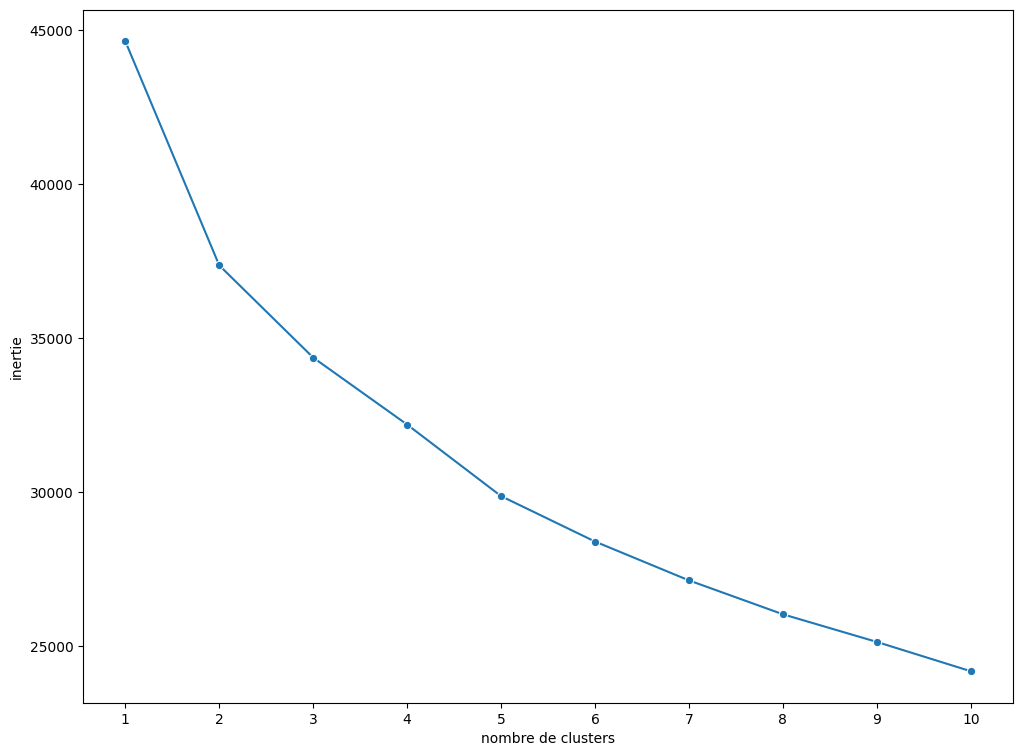

In [136]:
fig,ax = plt.subplots(figsize=(12,9))

sns.lineplot(x=k_list,y=inertia_list,marker="o")

ax.set_xlabel('nombre de clusters')
ax.set_xticks(ticks= [i for i in k_list])

ax.set_ylabel("inertie")

plt.show()

**Choix** : 
Notre choix va se porter sur 3 , car à 3 on observe une cassure et la ligne devient plus ou moins droite après.

### 3.5.2 Instanciation du k-means

In [140]:
# Nombre de clusters
n_clusters = 3

# Instanciation
kmeans = KMeans(n_clusters=n_clusters)

# Entrainement
kmeans.fit(X_Scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### 3.5.3 Clusters

In [153]:
# Recuperation des clusters
clusters = kmeans.labels_

# Dimensions des clusters
clusters.shape

(6378,)

In [ ]:
# Affichage de la sortie de value_counts
pd.Series.value_counts(clusters).sort_index()

0    2676
1    1497
2    2205
Name: count, dtype: int64

Nous avons bien 3 valeurs distinctes

### 3.5.4 Matrice des points projetés

In [144]:
# Recuperation de la matrice
X_Projected = pca.transform(X_Scaled)

# Transformation en dataframe
X_Projected = pd.DataFrame(X_Projected,columns=[f"PC{i+1}" for i in range(n_components)])


# Affichage d'un extrait
X_Projected.head()

,PC1,PC2,PC3,PC4,PC5
0,0.146100,0.573993,-0.353450,0.556818,-0.992946
1,-2.062010,-0.076767,1.707944,0.067799,-0.008377
2,2.571444,0.085977,0.302735,-0.717437,-0.362061
3,1.895338,1.633340,0.498512,-0.297402,-0.400153
4,1.080769,-1.572147,0.799988,-0.806268,-0.321819


In [146]:
# Affichage des dimensions
X_Projected.shape

(6378, 5)

### 3.5.6 Graphique de projection des points

In [155]:
def display_factorial_plans(X_Projected:pd.DataFrame,x_y:tuple,clusters:np.array,pca:PCA,figsize:tuple=(12,9)):
    """_summary_

    Args:
        X_Projected (pd.DataFrame): Matrice des points projetés
        x_y (tuple): Les indices des axes
        clusters (np.array): les clusters
        pca (PCA): le PCA
        figsize (tuple): figsize
    """

    # Transformation en array
    X_ = np.array(X_Projected)

    # Initialisation du graphique
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Nos axes
    x, y = x_y

    # Nuage de points
    sns.scatterplot(x=X_[:, x], y=X_[:, y], hue=clusters)

    # Labels des axes
    v1, v2 = [f"{pca.explained_variance_ratio_[k]:.2%}" for k in [x, y]]
    ax.set_xlabel(f"F{x+1} ({v1})")
    ax.set_ylabel(f"F{y+1} ({v2})")

    # On borne nos axes
    x_max = np.abs(X_[:, x]).max() * 1.1
    y_max = np.abs(X_[:, y]).max() * 1.1

    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom=-y_max, top=y_max)

    # On trace nos axes
    plt.plot([-x_max, x_max], [0, 0], c="grey", alpha=0.8)
    plt.plot([0, 0], [-y_max, y_max], c="grey", alpha=0.8)

    # Titre et Affichage du graphique
    plt.title(f"Projection des individus sur F{x+1} et F{y+1}")
    plt.show()

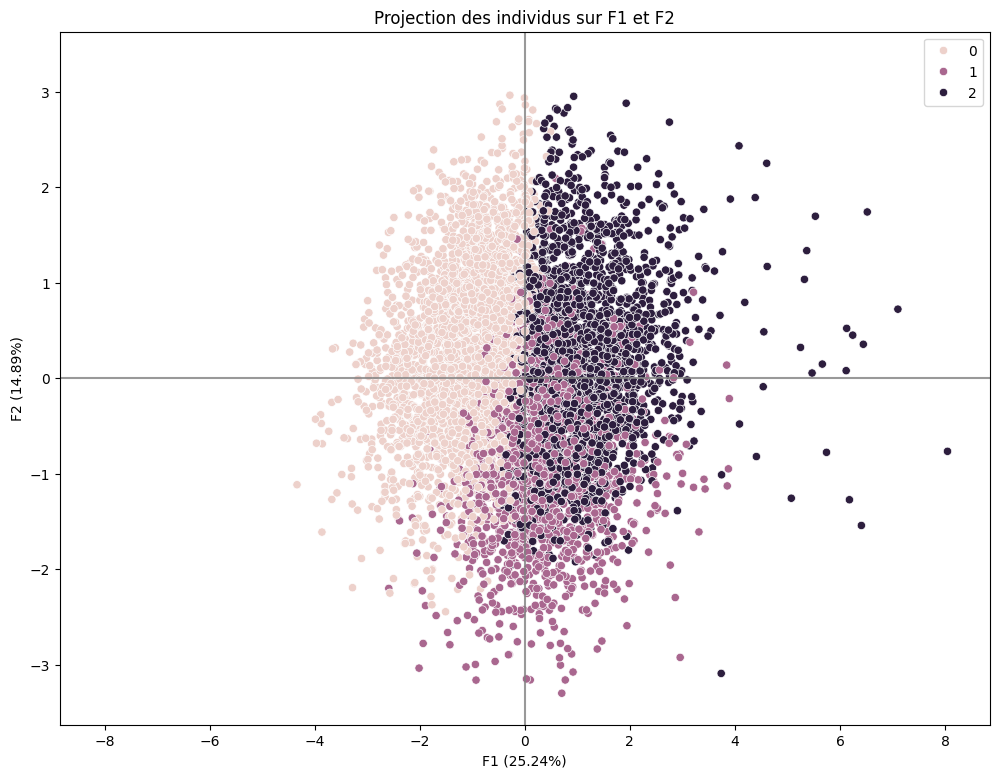

In [156]:
# Projection des individus sur F1 et F2
x_y=0,1
display_factorial_plans(X_Projected=X_Projected,x_y=x_y,pca=pca,clusters=clusters)

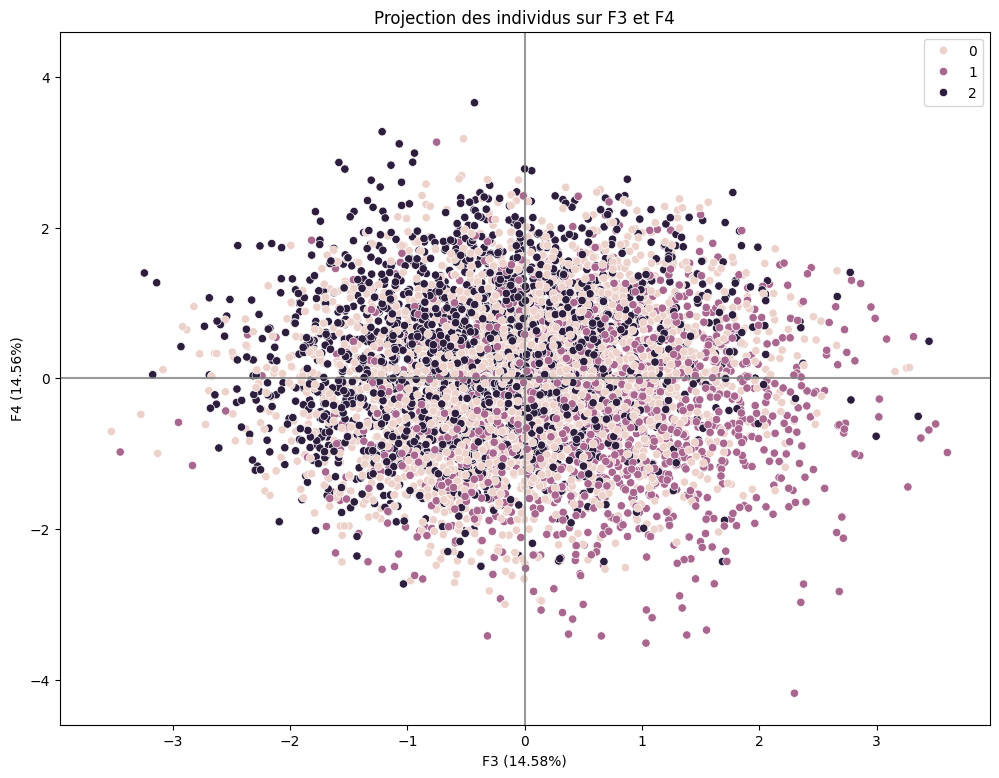

In [157]:
# Projection des individus sur F3 et F4
x_y = 2, 3
display_factorial_plans(X_Projected=X_Projected, x_y=x_y, pca=pca, clusters=clusters)